In [2]:
from boxmot.trackers import BotSort
import json
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


In [3]:

data_folder = Path(r"D:\Artificial intelligence Solutions\Semester 4\Computer Vision\Project\Data")
json_path = data_folder / "instances_default.json"
frames_dir = data_folder / "frames_tracking"
output_dir = data_folder / "output_tracking"
output_dir.mkdir(exist_ok=True)

# Load Ground-Truth Detections
print("Loading ground-truth JSON...")
with open(json_path, 'r') as f:
    coco_data = json.load(f)

frame_detections = {}
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    x, y, w, h = ann['bbox']
    class_id = ann['category_id']
    
    # Convert Navid [x, y, w, h] to BoxMOT [x1, y1, x2, y2, conf, class_id]
    detection = [x, y, x + w, y + h, 1.0, class_id]
    
    if img_id not in frame_detections:
        frame_detections[img_id] = []
    frame_detections[img_id].append(detection)
    
print(f"Successfully loaded annotations for {len(frame_detections)} frames!")

Loading ground-truth JSON...
Successfully loaded annotations for 21774 frames!


In [4]:
print("Initializing BoT-SORT ")
tracker = BotSort(
    model_weights=Path('osnet_x0_25_msmt17.pt'), 
    device='cuda:0', 
    fp16=True,
    with_reid=False,
    
    track_high_thresh=0.3,  # Lower the bar for confident detections
    track_low_thresh=0.05,  # Keep tracking even if the thermal signal gets faint
    new_track_thresh=0.4,   # Require a stronger signal to create a BRAND NEW animal ID
    track_buffer=60,        # Keep an animal "alive" in memory for 60 frames if it hides behind a tree
    match_thresh=0.9        # Make box matching much more relaxed
)
print("Tracker Ready")

Initializing BoT-SORT 


INFO     BotSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,          
         asso_func=iou, reid_model=None, track_high_thresh=0.3, track_low_thresh=0.05, new_track_thresh=0.4,       
         track_buffer=60, match_thresh=0.9, proximity_thresh=0.5, appearance_thresh=0.25, cmc_method=ecc,          
         frame_rate=30, fuse_first_associate=False, with_reid=False, model_weights=osnet_x0_25_msmt17.pt, fp16=True

Tracker Ready


In [5]:
#  Print first 5 entries from coco_data['images']
print(" COCO 'images' examples ")
for img in coco_data['images'][:5]:
    print(img)

# Print first 10 actual files in frames_dir
print("\n Actual files in frames_tracking (first 10) ")
frame_files = sorted(frames_dir.iterdir())[:10]
for f in frame_files:
    print(f.name)

 COCO 'images' examples 
{'id': 1, 'file_name': 'frames_detection/0/thermal/0_00008082.png', 'width': 1024, 'height': 1024}
{'id': 2, 'file_name': 'frames_detection/0/thermal/0_00008083.png', 'width': 1024, 'height': 1024}
{'id': 3, 'file_name': 'frames_detection/0/thermal/0_00008084.png', 'width': 1024, 'height': 1024}
{'id': 4, 'file_name': 'frames_detection/0/thermal/0_00008086.png', 'width': 1024, 'height': 1024}
{'id': 5, 'file_name': 'frames_detection/0/thermal/0_00008087.png', 'width': 1024, 'height': 1024}

 Actual files in frames_tracking (first 10) 
0_00008044.png
0_00008054.png
0_00008089.png
0_00008123.png
0_00008124.png
0_00008131.png
0_00008137.png
0_00008140.png
0_00008172.png
0_00008187.png


In [6]:
# Build the Smart Frame Map
print("Building the frame map ")

frame_map = {}

for img_info in coco_data['images']:
    img_id = img_info['id']
    
    # Extract just the clean filename (e.g., '0_00008082.png') from the long JSON path
    clean_name = Path(img_info['file_name']).name
    
    # Build the exact path to where this file sits on your D: drive
    actual_path = frames_dir / clean_name
    
    # If the file actually exists on your drive, link them together!
    if actual_path.exists():
        frame_map[img_id] = actual_path

print(f"Success Perfectly mapped {len(frame_map)} frames ready for tracking.")

Building the frame map 
Success Perfectly mapped 21509 frames ready for tracking.


In [8]:
print(f" Starting tracking pipeline for {len(frame_map)} frames ")

all_tracks = {} # Dictionary to keep a record of all tracks

#Sort the images by 'id' to ensure the tracker processes them in exact chronological order
for img_info in sorted(coco_data['images'], key=lambda x: x['id']):
    img_id = img_info['id']
    img_path = frame_map.get(img_id)
    
    if img_path is None:
        continue 
        
    # Load the thermal image
    frame = cv2.imread(str(img_path))
    if frame is None:
        print(f"Warning: Could not read image at {img_path.name}")
        continue
        
    # Get Navid ground-truth bounding boxes for this specific frame
    dets = frame_detections.get(img_id, [])
    
    # BoxMOT expects a NumPy array. If there are no animals, give it an empty array (0, 6)
    dets_array = np.array(dets) if dets else np.empty((0, 6))

    # RUN THE TRACKER!
    # tracked_objects returns a list of arrays [x1, y1, x2, y2, track_id, class_id, conf]
    tracked_objects = tracker.update(dets_array, frame)
    all_tracks[img_path.name] = tracked_objects

    # Draw the colored boxes and tracking IDs on the image
    for obj in tracked_objects:
        
        # ADDED [:7] HERE  This grabs the 7 values  need and ignores the extra metadata
        x1, y1, x2, y2, track_id, conf, class_id = obj[:7]
        
        # Draw a green rectangle around the animal
        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        
        # Write the unique ID number above the box
        cv2.putText(frame, f"ID: {int(track_id)}", (int(x1), int(y1) - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Save the finished image
    # Pad the ID with zeros (e.g., tracked_000001.png) so they sort perfectly in File Explorer
    clean_out_name = f"tracked_{img_id:06d}.png"
    cv2.imwrite(str(output_dir / clean_out_name), frame)
    
    # Print progress every 1,000 frames
    if img_id % 1000 == 0:
        print(f"Processed {img_id} frames...")

print("\n Tracking loop completely finished .")

# Extract Final Stats
unique_ids = set()
for tracks in all_tracks.values():
    if len(tracks) > 0:
        # Index 4 holds the track_id in the returned array
        unique_ids.update(tracks[:, 4].astype(int))

print(f"Total unique animals tracked in this dataset: {len(unique_ids)}")
print(f"Unique Track IDs: {sorted(unique_ids) if unique_ids else 'None'}")

 Starting tracking pipeline for 21509 frames 
Processed 1000 frames...
Processed 2000 frames...
Processed 3000 frames...
Processed 4000 frames...
Processed 5000 frames...
Processed 6000 frames...
Processed 7000 frames...
Processed 8000 frames...
Processed 9000 frames...
Processed 10000 frames...
Processed 11000 frames...
Processed 12000 frames...
Processed 13000 frames...
Processed 14000 frames...
Processed 15000 frames...
Processed 16000 frames...
Processed 17000 frames...
Processed 18000 frames...
Processed 19000 frames...
Processed 20000 frames...
Processed 21000 frames...

 Tracking loop completely finished .
Total unique animals tracked in this dataset: 6127
Unique Track IDs: [np.int64(417), np.int64(425), np.int64(437), np.int64(438), np.int64(452), np.int64(453), np.int64(461), np.int64(464), np.int64(466), np.int64(470), np.int64(472), np.int64(474), np.int64(486), np.int64(490), np.int64(493), np.int64(496), np.int64(504), np.int64(510), np.int64(532), np.int64(533), np.int64(

In [ ]:
# Generate the Final Tracking Video 

# 1. Setup the Video Writer
video_name = str(data_folder / "final_tracking_video.mp4")
fps = 10
frame_size = (1024, 1024) # From JSON metadata

# Use the 'mp4v' codec to create an MP4 file
fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
video_out = cv2.VideoWriter(video_name, fourcc, fps, frame_size)

frames_processed = 0

# Loop through the images agai
for img_info in sorted(coco_data['images'], key=lambda x: x['id']):
    img_id = img_info['id']
    frame_path = frame_map.get(img_id)
    
    if frame_path is None or not frame_path.exists():
        continue

    # Load the blank thermal frame
    frame = cv2.imread(str(frame_path))
    
    # Grab the tracking math already calculated for this specific frame
    tracks = all_tracks.get(frame_path.name, [])
    
    # Draw the visuals
    if len(tracks) > 0:
        for obj in tracks:
            x1, y1, x2, y2, track_id, conf, class_id = obj[:7]
            
            # Draw the bright green box
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            
            # Add the ID text above the box
            cv2.putText(frame, f"ID: {int(track_id)}", (int(x1), int(y1) - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Write this completed frame into our MP4 video file
    video_out.write(frame)
    
    frames_processed += 1
    if frames_processed % 1000 == 0:
        print(f"Added {frames_processed} frames to video...")

# Save 
video_out.release()
print(f" Success! Video saved as: {video_name}")

Added 1000 frames to video...
Added 2000 frames to video...
Added 3000 frames to video...
Added 4000 frames to video...
Added 5000 frames to video...
Added 6000 frames to video...
Added 7000 frames to video...
Added 8000 frames to video...
Added 9000 frames to video...
Added 10000 frames to video...
Added 11000 frames to video...
Added 12000 frames to video...
Added 13000 frames to video...
Added 14000 frames to video...
Added 15000 frames to video...
Added 16000 frames to video...
Added 17000 frames to video...
Added 18000 frames to video...
Added 19000 frames to video...
Added 20000 frames to video...
Added 21000 frames to video...
 Success! Video saved as: D:\Artificial intelligence Solutions\Semester 4\Computer Vision\Project\Data\final_tracking_video.mp4


Plotting filtered animal movement paths...
Diagnostic: Out of 6127 total IDs, only 29 are true long-term tracks.


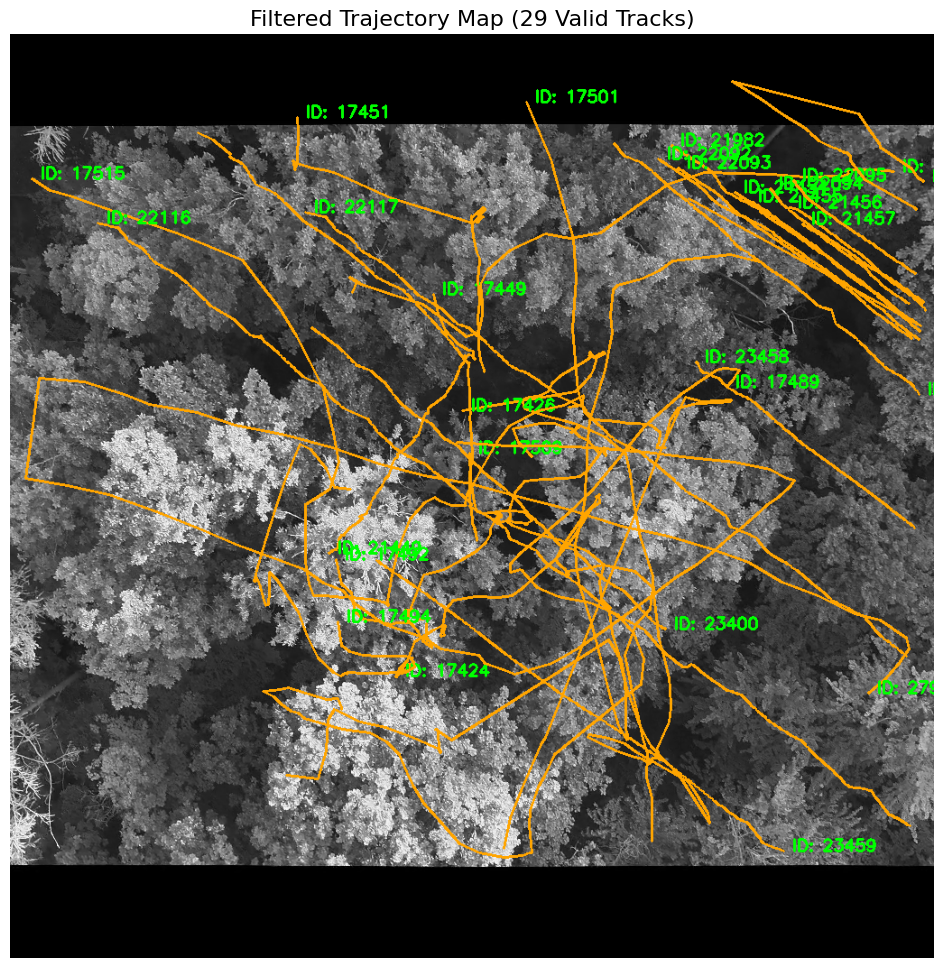

In [9]:
print("Plotting filtered animal movement paths...")

# 1. Grab the first available frame from our verified map
first_img_id = list(frame_map.keys())[0]
first_img_path = frame_map[first_img_id]

canvas = cv2.imread(str(first_img_path), cv2.IMREAD_GRAYSCALE)
canvas = cv2.normalize(canvas, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
canvas = cv2.cvtColor(canvas, cv2.COLOR_GRAY2BGR)

# 2. Extract all paths
paths = {}
for frame_name, tracks in all_tracks.items():
    if len(tracks) > 0:
        for obj in tracks:
            x1, y1, x2, y2, track_id, conf, class_id = obj[:7]
            center_x = int((x1 + x2) / 2)
            center_y = int((y1 + y2) / 2)

            if track_id not in paths:
                paths[track_id] = []
            paths[track_id].append((center_x, center_y))

MIN_FRAMES = 50

valid_paths = {t_id: pts for t_id, pts in paths.items() if len(pts) >= MIN_FRAMES}

print(f"Diagnostic: Out of {len(paths)} total IDs, only {len(valid_paths)} are true long-term tracks.")

# Draw ONLY the valid long-term paths
path_color = (0, 165, 255) # Orange
for t_id, points in valid_paths.items():
    # Draw the solid connecting lines
    for i in range(1, len(points)):
        cv2.line(canvas, points[i - 1], points[i], path_color, 2)
        
    # Draw the green ID text just ONCE at the very end of the long path
    last_pt = points[-1]
    cv2.putText(canvas, f"ID: {int(t_id)}", (last_pt[0] + 10, last_pt[1]), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Display directly in the Jupyter Notebook
canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(canvas_rgb)
plt.axis('off')
plt.title(f"Filtered Trajectory Map ({len(valid_paths)} Valid Tracks)", fontsize=16)
plt.show()